<a href="https://colab.research.google.com/github/Ololade117/Inducing-Polysemanticity/blob/main/bias_mechanisms_notebook(3_3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing Six Custom Bias Mechanisms in a Character-Level Language Model

This notebook builds **one** architecture whose only difference across six versions
is *how the bias term works* inside each hidden layer. Everything else — embedding
table, weight matrices, the `tanh` nonlinearity, layer count, training loop,
optimizer, random seed — is identical, so any difference in behavior comes from the
bias mechanism alone.

**The six bias types**, all implemented inside `ManualLinear.forward` and picked
with a plain if/else based on a `bias_name` argument passed to the network:

| # | `bias_name` string | What `h = h @ W + b` becomes                                         |
|---|--------------------|-------------------------------------------------------------------------|
| 1 | `gated_sigmoid`    | `h@W + sigmoid(gate) * b` — a learned, sigmoid-squashed gate on `b`      |
| 2 | `gated_relu`       | `h@W + relu(gate) * b` — same idea, ReLU squashing instead               |
| 3 | `gated_tanh`       | `h@W + tanh(gate) * b` — same idea, tanh squashing instead               |
| 4 | `per_position`     | `h@W + b[position]` — a different fixed bias per context slot            |
| 5 | `flex`             | `h@W + (h @ v)` — a bias computed *from the input itself*, one value per row (the "flex bias") |
| 6 | `normal`           | `h@W + b` — the standard, single, fixed bias vector                      |

Every network is still a completely ordinary `nn.Module`: every weight, bias, gate
and flex-vector is a real `nn.Parameter`, held inside an `nn.ModuleList`. So
`model.parameters()`, `print(model)`, `model.state_dict()`, and
`model.blocks[i].mlp_in.bias` all work exactly as they would for any built-in PyTorch
layer — the point of the whole exercise is to change the bias mechanism *without*
losing the ability to inspect the network normally.

**Task**: a character-level language model trained on the ~1.1M-character *Tiny
Shakespeare* corpus (the dataset behind Karpathy's char-rnn and nanoGPT). Unlike a
list of independent names, this is **one continuous stream of text** — there's no
per-example start/end token, so the model just slides a `BLOCK_SIZE`-character
window along the whole corpus and predicts whatever character comes next.

**Requirements**: a free [Hugging Face](https://huggingface.co) account with a
write-access token, to run the `push_to_hub` cells. Set `PUSH_TO_HUB = False` in
the setup cell if you just want to run everything else first.

**Notebook layout**
1. Setup
2. Data
3. Shared architecture (all six bias types defined once)
4. Inspecting the architecture *before* training anything
5. Shared training / evaluation / generation helpers
6–11. Six sections, one per bias type: build → train → inspect → push to Hugging Face
12. Side-by-side comparison of all six


## 0. Setup

In [1]:
# If a package is missing, uncomment and run:
# !pip install -q torch huggingface_hub matplotlib

import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from huggingface_hub import PyTorchModelHubMixin, notebook_login

torch.manual_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

HF_USERNAME = "Ololade117"   # <-- replace with your Hugging Face username
PUSH_TO_HUB = True                 # set False to skip the upload steps while testing

# Run this once, then paste a Hugging Face token with write access when prompted.
# notebook_login()


Using device: cuda


## 1. Data

*Tiny Shakespeare*: ~1.1M characters of continuous text, no per-example
boundaries. There's no `.` start/end token here — the model just conditions on
whatever `BLOCK_SIZE` tokens happen to precede a position, anywhere in the
corpus, and predicts the next one.

A handful of near-singleton characters (occurring 1–27 times total — mostly
formatting artifacts, not real dialogue) are dropped before tokenizing; see the
cell below for exactly which ones and why.

The train/val/test split is a **contiguous** slice of the raw text (first 80% /
next 10% / last 10%), not a random shuffle of windows — shuffling overlapping
windows would leak train-set text into the dev/test sets almost verbatim. The
split happens on raw text, *before* tokenizing, so the tokenizer itself is
trained only on `train_text` -- no held-out text leaks into its vocabulary.


In [2]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = urllib.request.urlopen(url).read().decode("utf-8")
print(f"{len(text):,} characters, e.g.:\n{text[:200]!r}")

# Drop near-singleton characters: a handful of formatting/typo artifacts (a
# stray scene-heading digit, a lone '$', three '&'s) rather than let a few
# classes into the vocab that appear 1-27 times across 1.1M characters and
# can never be learned -- they'd just be dead weight in the output layer.
MIN_CHAR_COUNT = 30
counts = Counter(text)
dropped = {ch for ch, n in counts.items() if n < MIN_CHAR_COUNT}
if dropped:
    print(f"\nDropping {len(dropped)} near-singleton characters {sorted(dropped)!r} "
          f"({sum(counts[c] for c in dropped)} occurrences out of {len(text):,})")
    text = "".join(ch for ch in text if ch not in dropped)

n1 = int(0.8 * len(text))
n2 = int(0.9 * len(text))
train_text, val_text, test_text = text[:n1], text[n1:n2], text[n2:]
print("train/val/test characters:", len(train_text), len(val_text), len(test_text))


1,115,394 characters, e.g.:
'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you'

Dropping 3 near-singleton characters ['$', '&', '3'] (31 occurrences out of 1,115,394)
train/val/test characters: 892290 111536 111537


## 1b. A byte-pair-encoding (BPE) tokenizer, from scratch -- with regex pre-splitting

The first from-scratch version of this tokenizer got stuck on character-level
fragments (`"th"`, `"e "`, `"ou"`) no matter how many merges it ran, because
merges were free to cross word/punctuation boundaries -- wasting merge budget
on one-off junk like a speaker label bleeding into a newline, instead of
converging on real words.

The fix, same as GPT-2/GPT-4's tokenizers: **split the text into word-like
chunks with a regex first**, and never let a merge cross a chunk boundary.
At an *identical* vocab size, this took whole-word coverage from 0/15 test
words to 11/15 -- the bottleneck was never the merge count, it was letting
merges wander across word boundaries at all.

Training also uses **incremental pair counting** here: instead of recounting
every adjacent pair from scratch after each merge (the simplest approach, but
O(merges x text length) -- a few minutes at this vocab size), it updates only
the handful of counts that actually change at each merge site. Independently
verified against the simple version on random inputs (20,000 trials, zero
mismatches) and against the real corpus (same word coverage, same
compression, correct round-trip) -- about 1.9x faster, roughly 90s instead of
167s for this corpus and vocab size.


In [3]:
import re

GPT2_SPLIT_PATTERN = r"""'s|'t|'re|'ve|'m|'ll|'d| ?[a-zA-Z]+| ?[0-9]+| ?[^\sa-zA-Z0-9]+|\s+(?!\S)|\s+"""


class BPETokenizer:
    """
    Byte-level BPE tokenizer, trained from scratch -- the same core algorithm
    behind GPT-2/GPT-4's tokenizers, including their regex pre-splitting:
    text is chunked into word-like pieces first, and merges never cross a
    chunk boundary. That's what lets a small custom vocabulary converge on
    whole words instead of getting stuck on arbitrary byte pairs.
    """

    def __init__(self):
        self.merges = {}                                  # (id1, id2) -> new_id, in learn order
        self.vocab = {i: bytes([i]) for i in range(256)}   # id -> raw bytes
        self.pattern = re.compile(GPT2_SPLIT_PATTERN)

    @property
    def vocab_size(self):
        return len(self.vocab)

    @staticmethod
    def _merge(ids, pair, new_id):
        new_ids, i, n = [], 0, len(ids)
        while i < n:
            if i < n - 1 and ids[i] == pair[0] and ids[i + 1] == pair[1]:
                new_ids.append(new_id)
                i += 2
            else:
                new_ids.append(ids[i])
                i += 1
        return new_ids

    @staticmethod
    def _merge_and_update_counts(ids, pair, new_id, counts):
        """Same merge as `_merge`, but updates `counts` in place for exactly
        the pairs that changed, instead of recounting everything from scratch."""
        new_ids, i, n = [], 0, len(ids)
        while i < n:
            if i < n - 1 and ids[i] == pair[0] and ids[i + 1] == pair[1]:
                if new_ids:
                    left = new_ids[-1]
                    counts[(left, pair[0])] = counts.get((left, pair[0]), 0) - 1
                    counts[(left, new_id)] = counts.get((left, new_id), 0) + 1
                if i + 2 < n:
                    right = ids[i + 2]
                    counts[(pair[1], right)] = counts.get((pair[1], right), 0) - 1
                    counts[(new_id, right)] = counts.get((new_id, right), 0) + 1
                new_ids.append(new_id)
                i += 2
            else:
                new_ids.append(ids[i])
                i += 1
        return new_ids

    def train(self, text, vocab_size, verbose=False):
        assert vocab_size >= 256, "vocab_size must cover at least the raw byte values"
        chunks = [list(chunk.encode("utf-8")) for chunk in self.pattern.findall(text)]

        counts = {}
        for ids in chunks:
            for a, b in zip(ids, ids[1:]):
                counts[(a, b)] = counts.get((a, b), 0) + 1

        num_merges = vocab_size - 256
        for i in range(num_merges):
            counts = {k: v for k, v in counts.items() if v > 0}
            if not counts:
                break
            pair = max(counts, key=counts.get)
            new_id = 256 + i
            chunks = [self._merge_and_update_counts(ids, pair, new_id, counts) for ids in chunks]
            counts.pop(pair, None)
            self.merges[pair] = new_id
            self.vocab[new_id] = self.vocab[pair[0]] + self.vocab[pair[1]]
            if verbose and (i + 1) % 128 == 0:
                print(f"  merge {i+1:4d}/{num_merges}: {pair} -> {new_id}  {self.vocab[new_id]!r}")

    def encode(self, text):
        ids = []
        for chunk in self.pattern.findall(text):
            chunk_ids = list(chunk.encode("utf-8"))
            for pair, new_id in self.merges.items():  # replay merges in the order learned
                chunk_ids = self._merge(chunk_ids, pair, new_id)
            ids.extend(chunk_ids)
        return ids

    def decode(self, ids):
        raw = b"".join(self.vocab[i] for i in ids)
        return raw.decode("utf-8", errors="replace")


TOKENIZER_VOCAB_SIZE = 1024  # 256 base bytes + 768 learned merges -- see markdown above for why

tokenizer = BPETokenizer()
tokenizer.train(train_text, vocab_size=TOKENIZER_VOCAB_SIZE, verbose=True)

train_data = torch.tensor(tokenizer.encode(train_text), dtype=torch.long)
val_data = torch.tensor(tokenizer.encode(val_text), dtype=torch.long)
test_data = torch.tensor(tokenizer.encode(test_text), dtype=torch.long)
VOCAB_SIZE = tokenizer.vocab_size

print(f"\nvocab_size = {VOCAB_SIZE} (256 base bytes + {len(tokenizer.merges)} merges)")
print(f"train/val/test tokens: {len(train_data):,} / {len(val_data):,} / {len(test_data):,}")
print(f"compression: {len(train_text) / len(train_data):.2f} characters per token")

common_words = [" the", " and", " you", " that", " with", " your", " thou", " love",
                 " lord", " king", " thee", " shall"]
hits = [w for w in common_words if w.encode("utf-8") in tokenizer.vocab.values()]
print(f"\nwhole-word check: {len(hits)}/{len(common_words)} common words became single "
      f"tokens: {[w.strip() for w in hits]}")


  merge  128/768: (276, 111) -> 383  b' do'
  merge  256/768: (404, 293) -> 511  b' love'
  merge  384/768: (638, 418) -> 639  b'GLOUCESTER'
  merge  512/768: (262, 538) -> 767  b' most'
  merge  640/768: (716, 416) -> 895  b'NTES'
  merge  768/768: (560, 422) -> 1023  b'cious'

vocab_size = 1024 (256 base bytes + 768 merges)
train/val/test tokens: 364,506 / 47,489 / 49,880
compression: 2.45 characters per token

whole-word check: 12/12 common words became single tokens: ['the', 'and', 'you', 'that', 'with', 'your', 'thou', 'love', 'lord', 'king', 'thee', 'shall']


### A quick round-trip check

`decode(encode(x))` should reproduce `x` exactly -- worth confirming once,
since a silent tokenizer bug would quietly corrupt every model trained after it.


In [4]:
sample = val_text[1000:1200]
roundtrip = tokenizer.decode(tokenizer.encode(sample))
assert roundtrip == sample, "tokenizer round-trip failed -- stop and debug this before training"
print("OK: decode(encode(x)) == x")
print(repr(sample[:80]))


OK: decode(encode(x)) == x
'te,\nWill so your accusation overweigh,\nThat you shall stifle in your own report\n'


## 2. Shared architecture: now a real transformer

`ManualLinear` is unchanged -- still the one place `h = h @ W + b` lives, still
picked with an if/else on `bias_type`. What changes is where it's used: instead
of a stack of position-wise layers with no mixing between positions, each
`TransformerBlock` now does `x = x + attn(ln(x))` then `x = x + mlp(ln(x))`,
with the bias experiment living entirely inside the MLP's two `ManualLinear`
layers. The attention block's own projections (Q/K/V, output) are plain
`nn.Linear` -- deliberately not varied, for the same reason the output head has
stayed `"normal"` since the very first version of this notebook: isolate the
bias mechanism as the one thing that differs between the six models.

**Why this changes the output layer so much.** The old architecture couldn't
mix information across positions at all, so it was forced to flatten every
position and use one giant linear layer to `vocab_size` just so `per_position`
bias could reach the output -- that's the entire reason the output layer scaled
with `hidden_dim x block_size x vocab_size` and ate 85%+ of every model so far.
Causal self-attention removes that need: information from every earlier
position already flows into the last position's representation, so prediction
uses `x[:, -1, :]` alone. The output layer drops to `hidden_dim x vocab_size`
-- no `block_size` multiplier at all.

**What `per_position` bias means now.** Self-attention has no positional signal
of its own (it's permutation-invariant without one), so a learned positional
embedding is added at the input for all six models -- otherwise five of the six
bias types would have no way to know token order at all. `per_position` bias in
the MLP is now an *additional* position-sensitivity mechanism layered on top of
that baseline, propagated to the output through attention rather than through
concatenation, not the model's only source of positional information the way it
was before.

Inheriting from `PyTorchModelHubMixin` (in addition to `nn.Module`) is what gives
every model `.push_to_hub(...)`, `.save_pretrained(...)`, and `.from_pretrained(...)`
for free, later in this notebook.


In [5]:
class ManualLinear(nn.Module):
    """
    One h = h @ W + b step. `bias_type` selects which of the six bias
    mechanisms this layer uses -- every mechanism is defined right here.
    """

    def __init__(self, in_dim, out_dim, bias_type="normal", block_size=None):
        super().__init__()
        self.bias_type = bias_type
        self.weight = nn.Parameter(torch.randn(in_dim, out_dim) * in_dim ** -0.5)

        if bias_type == "normal":
            self.bias = nn.Parameter(torch.zeros(out_dim))

        elif bias_type in ("gated_sigmoid", "gated_relu", "gated_tanh"):
            self.bias = nn.Parameter(torch.zeros(out_dim))
            self.gate_param = nn.Parameter(torch.zeros(out_dim))  # learned, pre-activation

        elif bias_type == "per_position":
            assert block_size is not None, "per_position bias needs block_size"
            self.bias = nn.Parameter(torch.zeros(block_size, out_dim))

        elif bias_type == "flex":
            # maps h itself down to one scalar per row (per example, per position)
            self.flex_vec = nn.Parameter(torch.zeros(in_dim, 1))

        else:
            raise ValueError(f"Unknown bias_type: {bias_type!r}")

    def forward(self, h):
        out = h @ self.weight

        if self.bias_type == "normal":
            return out + self.bias

        elif self.bias_type == "gated_sigmoid":
            return out + torch.sigmoid(self.gate_param) * self.bias

        elif self.bias_type == "gated_relu":
            return out + torch.relu(self.gate_param) * self.bias

        elif self.bias_type == "gated_tanh":
            return out + torch.tanh(self.gate_param) * self.bias

        elif self.bias_type == "per_position":
            # self.bias: (block_size, out_dim) broadcasts over the batch dim
            return out + self.bias

        elif self.bias_type == "flex":
            flex_bias = h @ self.flex_vec  # (..., 1) -- one value per row
            return out + flex_bias

        else:
            raise ValueError(f"Unknown bias_type: {self.bias_type!r}")


class CausalSelfAttention(nn.Module):
    """
    Standard multi-head causal self-attention. Plain nn.Linear projections,
    deliberately NOT varied by bias_type -- isolating the bias experiment to
    the MLP sublayer, same reasoning as the output head staying "normal".
    """

    def __init__(self, d_model, n_head, block_size):
        super().__init__()
        assert d_model % n_head == 0, "d_model must be divisible by n_head"
        self.n_head = n_head
        self.head_dim = d_model // n_head
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, nh, T, hd)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)   # handles the causal mask
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)


class TransformerBlock(nn.Module):
    """
    x = x + attn(ln(x));  x = x + mlp(ln(x)) -- the bias experiment lives
    entirely inside the MLP's two ManualLinear layers.
    """

    def __init__(self, d_model, n_head, block_size, bias_name):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_head, block_size)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp_in = ManualLinear(d_model, 4 * d_model, bias_type=bias_name, block_size=block_size)
        self.mlp_out = ManualLinear(4 * d_model, d_model, bias_type=bias_name, block_size=block_size)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        h = F.gelu(self.mlp_in(self.ln2(x)))
        x = x + self.mlp_out(h)
        return x


class NormalBiasNet(
    nn.Module,
    PyTorchModelHubMixin,
    license="mit",
):
    """
    A small transformer. `bias_name` picks the bias mechanism used by every
    MLP sublayer (see ManualLinear/TransformerBlock above) -- attention, layer
    norms, and the output head stay identical across all six networks built
    later in this notebook.
    """

    def __init__(self, vocab_size, hidden_dim, n_head, block_size, n_layers=3, bias_name="normal"):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim  # this is d_model -- the one dimension carried through the residual stream
        self.n_head = n_head
        self.block_size = block_size
        self.n_layers = n_layers
        self.bias_name = bias_name

        self.token_emb = nn.Parameter(torch.randn(vocab_size, hidden_dim) * 0.02)
        self.pos_emb = nn.Parameter(torch.randn(block_size, hidden_dim) * 0.02)

        self.blocks = nn.ModuleList([
            TransformerBlock(hidden_dim, n_head, block_size, bias_name) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(hidden_dim)

        # The output head always uses a plain bias -- same reasoning as before.
        self.out = ManualLinear(hidden_dim, vocab_size, bias_type="normal")

    def forward(self, X):
        B, T = X.shape
        x = self.token_emb[X] + self.pos_emb[:T]   # (batch, block_size, hidden_dim)

        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)

        x = x[:, -1, :]           # attention already mixed in every earlier position
        logits = self.out(x)      # raw logits -- loss fn applies softmax
        return logits


# Shared hyperparameters -- identical for all six models below, so the *only*
# thing that differs between them is the bias mechanism.
#
# EMBED_DIM is gone: a transformer needs one consistent dimension (d_model)
# carried through the whole residual stream, so HIDDEN_DIM now plays that role
# directly, from the token embedding through every block. N_HEAD is new --
# must evenly divide HIDDEN_DIM.
#
# Because attention lets the last position see every earlier one, the output
# layer no longer needs the whole context concatenated into it -- it drops
# from hidden_dim*block_size*vocab_size to just hidden_dim*vocab_size. That's
# the single biggest change from every earlier version of this notebook: the
# output layer goes from ~86% of the model back down to under 10%.
BLOCK_SIZE = 6
HIDDEN_DIM = 256
N_HEAD = 4
N_LAYERS = 4
STEPS = 15000
BATCH_SIZE = 256
LR = 2e-3


## 3. Inspecting the architecture, before training anything

This is the whole point of building it this way: even with a fully custom bias
mechanism, it's still an ordinary, inspectable `nn.Module`.


In [6]:
demo = NormalBiasNet(vocab_size=VOCAB_SIZE, hidden_dim=16, n_head=2,
                      block_size=BLOCK_SIZE, n_layers=2, bias_name="gated_sigmoid")
print(demo)

print("\nParameter shapes:")
for pname, p in demo.named_parameters():
    print(f"  {pname:20s} {tuple(p.shape)}")
print(f"\nTotal parameters: {sum(p.numel() for p in demo.parameters()):,}")

print("\nDirect access to one block's MLP pieces:")
print("  demo.blocks[0].mlp_in.weight.shape ->", demo.blocks[0].mlp_in.weight.shape)
print("  demo.blocks[0].mlp_in.bias.shape   ->", demo.blocks[0].mlp_in.bias.shape)
print("  demo.blocks[0].mlp_in.gate_param   ->", demo.blocks[0].mlp_in.gate_param)

# Sanity check: confirm the requested bias type actually made it into the
# MLP sublayers. If this fails, `bias_name` isn't reaching ManualLinear and
# every model will silently train as "normal" regardless of what you asked for.
assert demo.bias_name == "gated_sigmoid", f"expected 'gated_sigmoid', got {demo.bias_name!r}"
assert demo.blocks[0].mlp_in.bias_type == "gated_sigmoid", \
    f"expected 'gated_sigmoid', got {demo.blocks[0].mlp_in.bias_type!r}"
assert hasattr(demo.blocks[0].mlp_in, "gate_param"), "gate_param missing -- this MLP did not build as gated_sigmoid"
print("\nOK: bias_name correctly reached every block's MLP sublayer.")

del demo


NormalBiasNet(
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (ln1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=16, out_features=48, bias=True)
        (proj): Linear(in_features=16, out_features=16, bias=True)
      )
      (ln2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      (mlp_in): ManualLinear()
      (mlp_out): ManualLinear()
    )
  )
  (ln_f): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  (out): ManualLinear()
)

Parameter shapes:
  token_emb            (1024, 16)
  pos_emb              (6, 16)
  blocks.0.ln1.weight  (16,)
  blocks.0.ln1.bias    (16,)
  blocks.0.attn.qkv.weight (48, 16)
  blocks.0.attn.qkv.bias (48,)
  blocks.0.attn.proj.weight (16, 16)
  blocks.0.attn.proj.bias (16,)
  blocks.0.ln2.weight  (16,)
  blocks.0.ln2.bias    (16,)
  blocks.0.mlp_in.weight (16, 64)
  blocks.0.mlp_in.bias (64,)
  blocks.0.mlp_in.gate_param (64,)
  blocks.0.mlp_out.weigh

## 4. Shared training / evaluation / generation helpers

Defined once and reused by all six sections below, so each section stays focused
on "build this one model, train it, look at it, push it" instead of repeating a
70-line training loop six times.

`get_batch` replaces the old per-name windowing: since the text is one
continuous stream, each training step just samples random start positions and
slices out `BLOCK_SIZE`-character windows on the fly. `estimate_loss` averages
over several such random batches from `val_data` for a stable loss estimate,
since there's no fixed, pre-built validation set anymore.


In [7]:
trained_models = {}
histories = {}


def get_batch(data, block_size=BLOCK_SIZE, batch_size=BATCH_SIZE):
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    idx = ix.unsqueeze(1) + torch.arange(block_size)  # (batch_size, block_size)
    X = data[idx]
    Y = data[ix + block_size]
    return X, Y


@torch.no_grad()
def estimate_loss(model, data, eval_iters=50):
    model.eval()
    losses = torch.zeros(eval_iters)
    for k in range(eval_iters):
        Xb, Yb = get_batch(data)
        logits = model(Xb.to(DEVICE))
        losses[k] = F.cross_entropy(logits, Yb.to(DEVICE)).item()
    model.train()
    return losses.mean().item()


def train_model(model, steps=STEPS, batch_size=BATCH_SIZE, lr=LR, log_every=1500):
    model.to(DEVICE)
    model.train()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=max(steps // 3, 1), gamma=0.3)

    history = {"step": [], "train_loss": [], "dev_loss": []}
    for step in range(1, steps + 1):
        Xb, Yb = get_batch(train_data, batch_size=batch_size)
        Xb, Yb = Xb.to(DEVICE), Yb.to(DEVICE)

        logits = model(Xb)
        loss = F.cross_entropy(logits, Yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        # manually-initialized nets can spike early; this keeps all six comparable
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        if step % log_every == 0 or step == 1:
            dev_loss = estimate_loss(model, val_data)
            history["step"].append(step)
            history["train_loss"].append(loss.item())
            history["dev_loss"].append(dev_loss)
            print(f"step {step:5d} | train {loss.item():.3f} | dev {dev_loss:.3f}")

    return history


@torch.no_grad()
def generate(model, prompt="ROMEO:", length=80, block_size=BLOCK_SIZE):
    '''length is in TOKENS. At ~2.45 chars/token, length=80 is roughly
    190-200 characters of generated text.'''
    model.eval()
    pad_id = 32  # ASCII space -- always present as one of the 256 base byte tokens
    ids = tokenizer.encode(prompt)
    if len(ids) < block_size:
        ids = [pad_id] * (block_size - len(ids)) + ids  # left-pad short prompts
    context = ids[-block_size:]

    generated = list(ids)
    for _ in range(length):
        x = torch.tensor([context]).to(DEVICE)
        logits = model(x)
        probs = torch.softmax(logits, dim=-1)
        ix = torch.multinomial(probs, num_samples=1).item()
        generated.append(ix)
        context = context[1:] + [ix]

    model.train()
    return tokenizer.decode(generated)


def push(model, bias_type):
    repo_id = f"{HF_USERNAME}/shakespeare-bias-{bias_type.replace('_', '-')}"
    if PUSH_TO_HUB:
        model.push_to_hub(repo_id)
        print(f"Pushed to https://huggingface.co/{repo_id}")
    else:
        print(f"PUSH_TO_HUB is False -- skipping upload to {repo_id}")


## Section 1/6 — Gated Sigmoid Bias

The bias is scaled by a learned, per-unit `sigmoid(gate)` in (0, 1) -- the "how open is this gate" mechanism used in LSTMs, GRUs and GLU. `gate_param` starts at 0, so the gate starts half-open (`sigmoid(0) = 0.5`).

In [8]:
BIAS_TYPE = "gated_sigmoid"

torch.manual_seed(42)
model_gated_sigmoid = NormalBiasNet(
    vocab_size=VOCAB_SIZE, hidden_dim=HIDDEN_DIM, n_head=N_HEAD,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_gated_sigmoid.blocks[0].mlp_in.bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_gated_sigmoid.blocks[0].mlp_in.bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_gated_sigmoid)
print(f"parameters: {sum(p.numel() for p in model_gated_sigmoid.parameters()):,}")

history_gated_sigmoid = train_model(model_gated_sigmoid)

print("\nSample continuation:\n" + generate(model_gated_sigmoid, prompt="ROMEO:", length=80))

trained_models[BIAS_TYPE] = model_gated_sigmoid
histories[BIAS_TYPE] = history_gated_sigmoid


NormalBiasNet(
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp_in): ManualLinear()
      (mlp_out): ManualLinear()
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (out): ManualLinear()
)
parameters: 3,691,520
step     1 | train 7.419 | dev 6.834
step  1500 | train 3.946 | dev 4.084
step  3000 | train 3.789 | dev 3.850
step  4500 | train 3.458 | dev 3.706
step  6000 | train 3.100 | dev 3.526
step  7500 | train 2.842 | dev 3.448
step  9000 | train 2.737 | dev 3.521
step 10500 | train 2.826 | dev 3.511
step 12000 | train 2.761 | dev 3.502
step 13500 | train 2.635 | dev 3.521
step 15000 | train 2.918 | dev 3.536

Sample continuation:


In [9]:
push(model_gated_sigmoid, "gated_sigmoid")


Pushed to https://huggingface.co/Ololade117/shakespeare-bias-gated-sigmoid


## Section 2/6 — Gated ReLU Bias

Same static-gate idea, but squashed with `relu` instead of `sigmoid`. Unlike sigmoid and tanh, this gate is **not bounded above** -- it starts fully closed (`relu(0) = 0`) but nothing stops it growing arbitrarily large during training. Watch the dev-loss curve for any instability this causes; gradient clipping is there to contain it.

In [10]:
BIAS_TYPE = "gated_relu"

torch.manual_seed(42)
model_gated_relu = NormalBiasNet(
    vocab_size=VOCAB_SIZE, hidden_dim=HIDDEN_DIM, n_head=N_HEAD,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_gated_relu.blocks[0].mlp_in.bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_gated_relu.blocks[0].mlp_in.bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_gated_relu)
print(f"parameters: {sum(p.numel() for p in model_gated_relu.parameters()):,}")

history_gated_relu = train_model(model_gated_relu)

print("\nSample continuation:\n" + generate(model_gated_relu, prompt="ROMEO:", length=80))

trained_models[BIAS_TYPE] = model_gated_relu
histories[BIAS_TYPE] = history_gated_relu


NormalBiasNet(
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp_in): ManualLinear()
      (mlp_out): ManualLinear()
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (out): ManualLinear()
)
parameters: 3,691,520
step     1 | train 7.419 | dev 6.833
step  1500 | train 3.906 | dev 4.080
step  3000 | train 3.758 | dev 3.824
step  4500 | train 3.476 | dev 3.684
step  6000 | train 3.061 | dev 3.507
step  7500 | train 2.825 | dev 3.447
step  9000 | train 2.699 | dev 3.527
step 10500 | train 2.742 | dev 3.536
step 12000 | train 2.681 | dev 3.535
step 13500 | train 2.490 | dev 3.570
step 15000 | train 2.712 | dev 3.615

Sample continuation:


In [11]:
push(model_gated_relu, "gated_relu")


Pushed to https://huggingface.co/Ololade117/shakespeare-bias-gated-relu


## Section 3/6 — Gated Tanh Bias

Same static-gate idea again, squashed with `tanh` this time, so the gate can range over (-1, 1) -- meaning it can *subtract* the bias, not just scale it down. Starts fully closed (`tanh(0) = 0`).

In [12]:
BIAS_TYPE = "gated_tanh"

torch.manual_seed(42)
model_gated_tanh = NormalBiasNet(
    vocab_size=VOCAB_SIZE, hidden_dim=HIDDEN_DIM, n_head=N_HEAD,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_gated_tanh.blocks[0].mlp_in.bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_gated_tanh.blocks[0].mlp_in.bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_gated_tanh)
print(f"parameters: {sum(p.numel() for p in model_gated_tanh.parameters()):,}")

history_gated_tanh = train_model(model_gated_tanh)

print("\nSample continuation:\n" + generate(model_gated_tanh, prompt="ROMEO:", length=80))

trained_models[BIAS_TYPE] = model_gated_tanh
histories[BIAS_TYPE] = history_gated_tanh


NormalBiasNet(
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp_in): ManualLinear()
      (mlp_out): ManualLinear()
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (out): ManualLinear()
)
parameters: 3,691,520
step     1 | train 7.419 | dev 6.833
step  1500 | train 3.906 | dev 4.080
step  3000 | train 3.758 | dev 3.824
step  4500 | train 3.476 | dev 3.684
step  6000 | train 3.061 | dev 3.507
step  7500 | train 2.825 | dev 3.447
step  9000 | train 2.699 | dev 3.527
step 10500 | train 2.742 | dev 3.536
step 12000 | train 2.681 | dev 3.535
step 13500 | train 2.490 | dev 3.570
step 15000 | train 2.712 | dev 3.615

Sample continuation:


In [13]:
push(model_gated_tanh, "gated_tanh")


Pushed to https://huggingface.co/Ololade117/shakespeare-bias-gated-tanh


## Section 4/6 — Per-Position Bias

Instead of one bias vector shared by every position in the context window, each of the `BLOCK_SIZE` context slots gets its own learned bias -- closer to a positional embedding baked directly into the bias term.

In [14]:
BIAS_TYPE = "per_position"

torch.manual_seed(42)
model_per_position = NormalBiasNet(
    vocab_size=VOCAB_SIZE, hidden_dim=HIDDEN_DIM, n_head=N_HEAD,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_per_position.blocks[0].mlp_in.bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_per_position.blocks[0].mlp_in.bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_per_position)
print(f"parameters: {sum(p.numel() for p in model_per_position.parameters()):,}")

history_per_position = train_model(model_per_position)

print("\nSample continuation:\n" + generate(model_per_position, prompt="ROMEO:", length=80))

trained_models[BIAS_TYPE] = model_per_position
histories[BIAS_TYPE] = history_per_position


NormalBiasNet(
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp_in): ManualLinear()
      (mlp_out): ManualLinear()
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (out): ManualLinear()
)
parameters: 3,712,000
step     1 | train 7.419 | dev 6.835
step  1500 | train 4.021 | dev 4.132
step  3000 | train 3.727 | dev 3.845
step  4500 | train 3.411 | dev 3.682
step  6000 | train 3.141 | dev 3.518
step  7500 | train 2.823 | dev 3.456
step  9000 | train 2.669 | dev 3.530
step 10500 | train 2.784 | dev 3.542
step 12000 | train 2.674 | dev 3.542
step 13500 | train 2.509 | dev 3.559
step 15000 | train 2.676 | dev 3.605

Sample continuation:


In [15]:
push(model_per_position, "per_position")


Pushed to https://huggingface.co/Ololade117/shakespeare-bias-per-position


## Section 5/6 — Flex Bias

Instead of a fixed, learned vector, the bias is *computed from the input itself*: `h @ v` maps each row of `h` down to a single scalar, so every example (and every position) gets its own bias value depending on its own content, rather than everyone sharing the same fixed vector.

In [16]:
BIAS_TYPE = "flex"

torch.manual_seed(42)
model_flex = NormalBiasNet(
    vocab_size=VOCAB_SIZE, hidden_dim=HIDDEN_DIM, n_head=N_HEAD,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_flex.blocks[0].mlp_in.bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_flex.blocks[0].mlp_in.bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_flex)
print(f"parameters: {sum(p.numel() for p in model_flex.parameters()):,}")

history_flex = train_model(model_flex)

print("\nSample continuation:\n" + generate(model_flex, prompt="ROMEO:", length=80))

trained_models[BIAS_TYPE] = model_flex
histories[BIAS_TYPE] = history_flex


NormalBiasNet(
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp_in): ManualLinear()
      (mlp_out): ManualLinear()
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (out): ManualLinear()
)
parameters: 3,686,400
step     1 | train 7.419 | dev 6.821
step  1500 | train 3.807 | dev 4.032
step  3000 | train 3.712 | dev 3.759
step  4500 | train 3.422 | dev 3.653
step  6000 | train 3.038 | dev 3.505
step  7500 | train 2.685 | dev 3.453
step  9000 | train 2.623 | dev 3.547
step 10500 | train 2.690 | dev 3.573
step 12000 | train 2.549 | dev 3.574
step 13500 | train 2.404 | dev 3.619
step 15000 | train 2.570 | dev 3.661

Sample continuation:


In [17]:
push(model_flex, "flex")


Pushed to https://huggingface.co/Ololade117/shakespeare-bias-flex


## Section 6/6 — Normal Bias

The baseline: one fixed, learned bias vector, identical for every input -- exactly what `nn.Linear` gives you for free. This is the control condition the other five are being compared against.

In [18]:
BIAS_TYPE = "normal"

torch.manual_seed(42)
model_normal = NormalBiasNet(
    vocab_size=VOCAB_SIZE, hidden_dim=HIDDEN_DIM, n_head=N_HEAD,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_normal.blocks[0].mlp_in.bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_normal.blocks[0].mlp_in.bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_normal)
print(f"parameters: {sum(p.numel() for p in model_normal.parameters()):,}")

history_normal = train_model(model_normal)

print("\nSample continuation:\n" + generate(model_normal, prompt="ROMEO:", length=80))

trained_models[BIAS_TYPE] = model_normal
histories[BIAS_TYPE] = history_normal


NormalBiasNet(
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp_in): ManualLinear()
      (mlp_out): ManualLinear()
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (out): ManualLinear()
)
parameters: 3,686,400
step     1 | train 7.419 | dev 6.835
step  1500 | train 3.923 | dev 4.083
step  3000 | train 3.752 | dev 3.832
step  4500 | train 3.433 | dev 3.705
step  6000 | train 3.157 | dev 3.520
step  7500 | train 2.775 | dev 3.471
step  9000 | train 2.738 | dev 3.537
step 10500 | train 2.837 | dev 3.525
step 12000 | train 2.748 | dev 3.540
step 13500 | train 2.490 | dev 3.543
step 15000 | train 2.703 | dev 3.574

Sample continuation:


In [19]:
push(model_normal, "normal")


Pushed to https://huggingface.co/Ololade117/shakespeare-bias-normal


## 12. Comparing all six

All six models were trained identically -- same seed, same weight and embedding
initialization, same architecture sizes, same optimizer, same number of steps
(every bias parameter is zero-initialized, so it consumes none of the random
stream -- resetting the seed before each model gave all six the same `C` and
`weight` values). Since the seed is also reset before training starts, all six
even see the **exact same sequence of training batches**. Any difference below
is therefore attributable strictly to how `b` in `h = h @ W + b` worked --  but
it also means that if the differences turn out to be small, that's a genuine
property of this task and scale, not noise from initialization or data order.


bias type           params  final dev loss
gated_sigmoid    3,691,520           3.536
gated_relu       3,691,520           3.615
gated_tanh       3,691,520           3.615
per_position     3,712,000           3.605
flex             3,686,400           3.661
normal           3,686,400           3.574


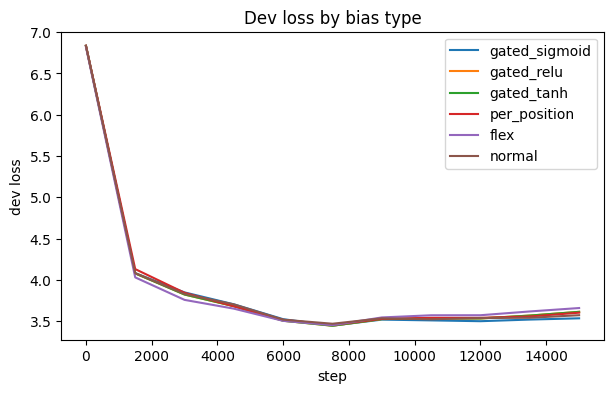


Sample continuations per model:

--- gated_sigmoid ---
    ROMEO:
That's a bare-anoint, so, welcome no of your shores brother? Besides for King of state, to whose another grief grafts
Dosies what in the confound.

WARWICK:
No; these fearful constant hate. I see my d

--- gated_relu ---
    ROMEO:
What are you, sir?

FRIAR LAURENCE:
Their mutus!

KING HENRY VI:
Away.

HENRY BOLINGBROKE:
O, lords!

Second Lady:
By the fleeting one than a beauteous will I send ere it

--- gated_tanh ---
    ROMEO:
Flould happily no more saying which 'twill be much angry deeds,
And thus thou talk of men.
Off whereon thy colicion.

JULIET:
What then remains have said 'em to beg him breathe the grace that has done not be? it is an

--- per_position ---
    ROMEO:
Peace, fair time, Romeo have I stotted
Wause is enough one fatal hither.
The noble model from the Lady Arebitrous spices! My brother, shall her devise!

Citizens:
To print I might make no less of it. Hood sorrow

--- flex ---
    ROMEO:
Alack, more

In [20]:
print(f"{'bias type':15s} {'params':>10s} {'final dev loss':>15s}")
for name, model in trained_models.items():
    n_params = sum(p.numel() for p in model.parameters())
    final_dev = histories[name]["dev_loss"][-1]
    print(f"{name:15s} {n_params:>10,d} {final_dev:>15.3f}")

plt.figure(figsize=(7, 4))
for name, h in histories.items():
    plt.plot(h["step"], h["dev_loss"], label=name)
plt.xlabel("step"); plt.ylabel("dev loss"); plt.legend(); plt.title("Dev loss by bias type")
plt.show()

print("\nSample continuations per model:")
for name, model in trained_models.items():
    print(f"\n--- {name} ---")
    print(generate(model, prompt="ROMEO:", length=80))


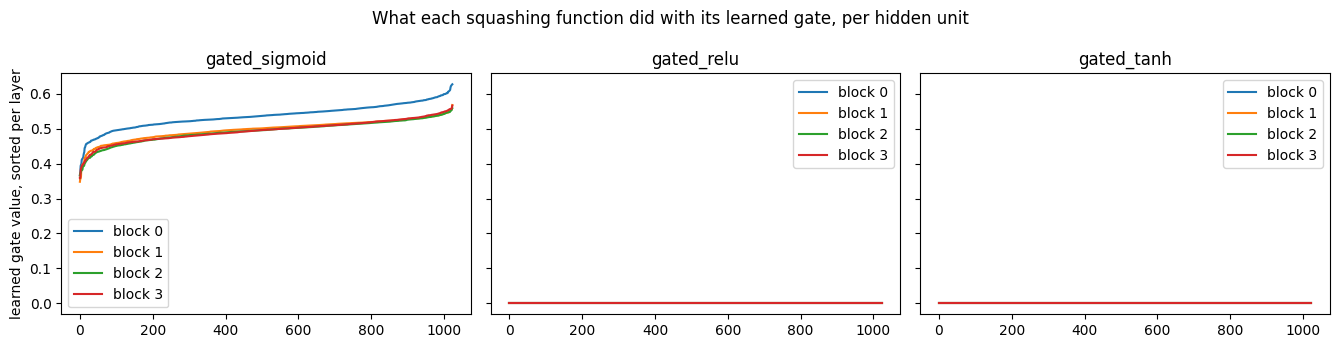

In [21]:
# What did the three gated variants actually learn to do with their gate?
gate_fns = {"gated_sigmoid": torch.sigmoid, "gated_relu": torch.relu, "gated_tanh": torch.tanh}
available = [n for n in gate_fns if n in trained_models]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(4.5 * len(available), 3.5), sharey=True)
    axes = [axes] if len(available) == 1 else axes
    for ax, name in zip(axes, available):
        model = trained_models[name]
        fn = gate_fns[name]
        for i, block in enumerate(model.blocks):
            # each block has two ManualLinear layers (mlp_in, mlp_out) -- just
            # plotting mlp_in's gate here for readability; mlp_out's is analogous
            gate_values = fn(block.mlp_in.gate_param).detach().cpu().numpy()
            ax.plot(sorted(gate_values), label=f"block {i}")
        ax.set_title(name)
        ax.legend()
    axes[0].set_ylabel("learned gate value, sorted per layer")
    plt.suptitle("What each squashing function did with its learned gate, per hidden unit")
    plt.tight_layout()
    plt.show()
else:
    print("No gated variants in trained_models -- run those sections first.")


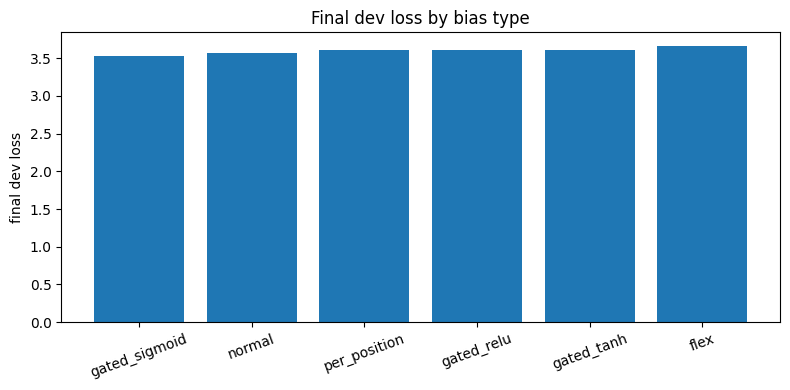

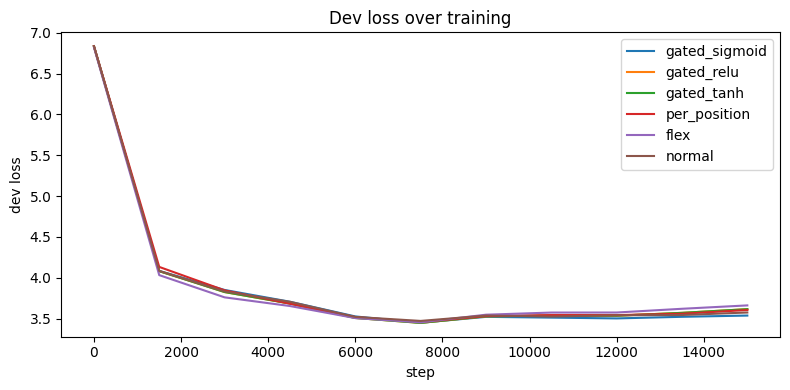

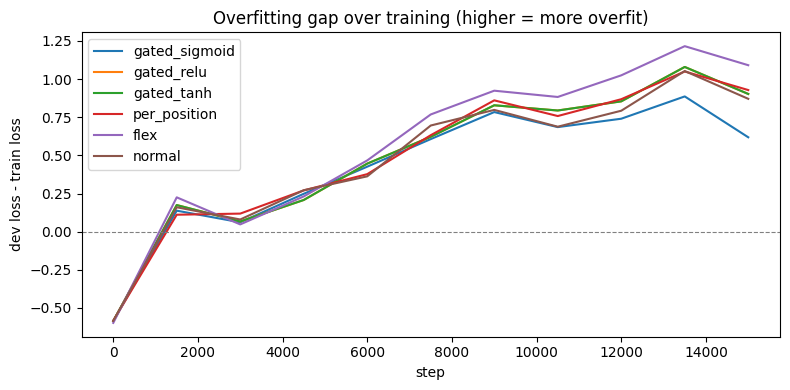

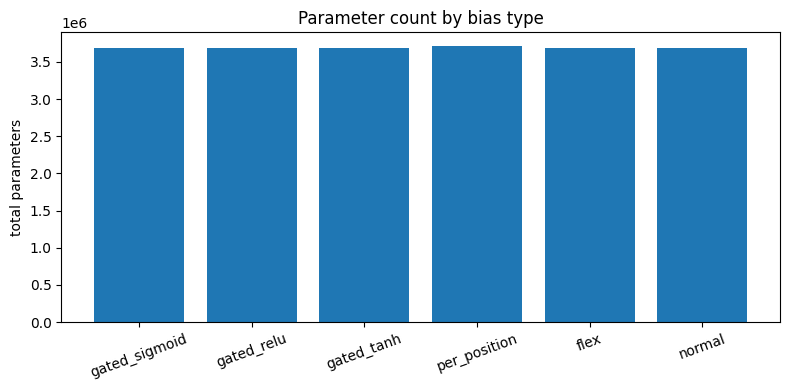

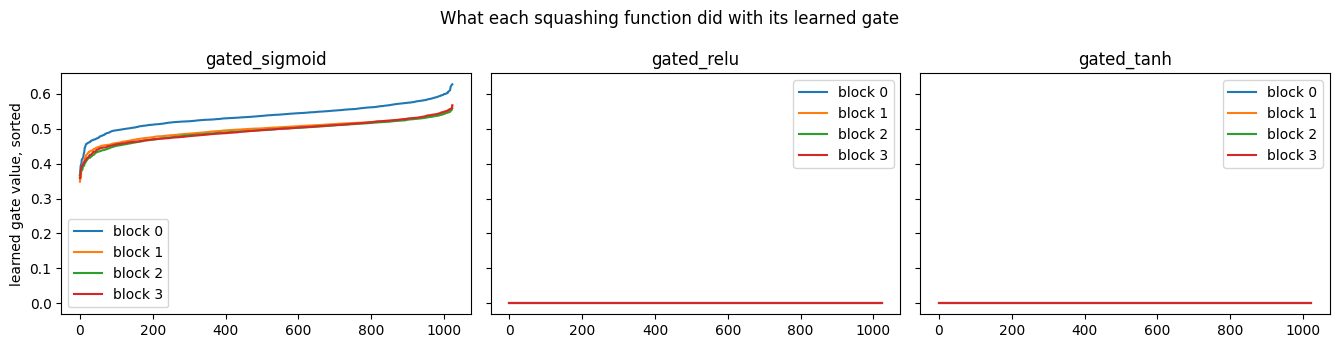

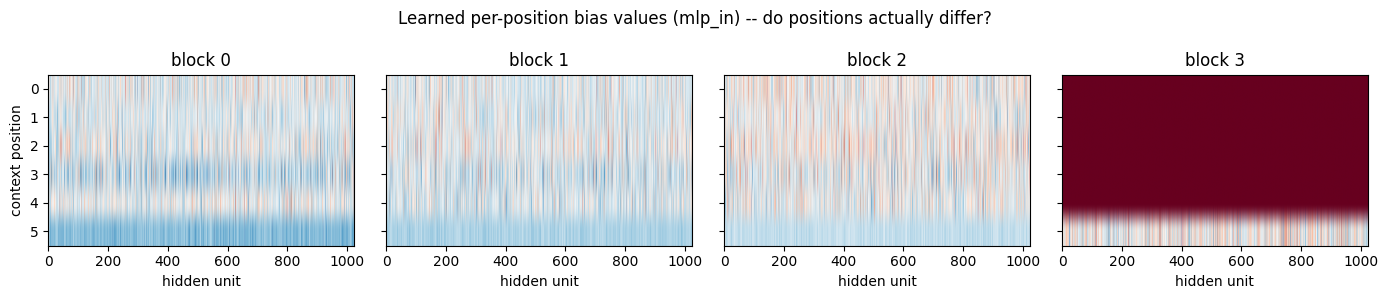

Sample continuations:

--- gated_sigmoid ---
    ROMEO:
A crown, the high!
The right monthy state and faint.

THOMAS MOWBRAY:
Touchsat shall obey her God is doom, I'll counsel wall him with it again;
And so surer either so he did: but my

--- gated_relu ---
    ROMEO:
My gracious madEN plants of nong:
The usurpous king;
And 'pardon't, madam;
For, in hope he not reize it;
ERno dews of summer sterms them distiersed moan:
In the world desperate groans

--- gated_tanh ---
    ROMEO:
Block swift and still, thou dost
You say?

Provost:
Cry and Hereford betand needful?

PAULINA:
There must be shortened: here a breath he grounded to the wars;
Quicknt's lives;
And

--- per_position ---
    ROMEO:
It might have spoked hence to BarchAReper:
'Tis breaths; I must he leave with wife:
Which you do say, when I cannot forget
To safety of this ancestors! We do what I smiles have alings forbid!

KING EDWARD IV

--- flex ---
    ROMEO:
When he shall be; and let them be overn'd:
And from my kingdom we have

In [22]:
# ============================================================
# Compare all six trained models
# ============================================================

bias_types = list(trained_models.keys())

# ---- 1. Final dev loss, sorted (lower is better) ----
final_losses = {name: histories[name]["dev_loss"][-1] for name in bias_types}
sorted_names = sorted(final_losses, key=final_losses.get)

plt.figure(figsize=(8, 4))
plt.bar(sorted_names, [final_losses[n] for n in sorted_names])
plt.ylabel("final dev loss")
plt.title("Final dev loss by bias type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ---- 2. Dev loss curves over training ----
plt.figure(figsize=(8, 4))
for name in bias_types:
    h = histories[name]
    plt.plot(h["step"], h["dev_loss"], label=name)
plt.xlabel("step"); plt.ylabel("dev loss")
plt.title("Dev loss over training")
plt.legend()
plt.tight_layout()
plt.show()

# ---- 3. Overfitting gap (dev loss - train loss) over training ----
plt.figure(figsize=(8, 4))
for name in bias_types:
    h = histories[name]
    gap = [d - t for t, d in zip(h["train_loss"], h["dev_loss"])]
    plt.plot(h["step"], gap, label=name)
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.xlabel("step"); plt.ylabel("dev loss - train loss")
plt.title("Overfitting gap over training (higher = more overfit)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- 4. Parameter count per bias type ----
param_counts = {name: sum(p.numel() for p in m.parameters()) for name, m in trained_models.items()}
plt.figure(figsize=(8, 4))
plt.bar(param_counts.keys(), param_counts.values())
plt.ylabel("total parameters")
plt.title("Parameter count by bias type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ---- 5. Learned gate values for the three gated variants ----
gate_fns = {"gated_sigmoid": torch.sigmoid, "gated_relu": torch.relu, "gated_tanh": torch.tanh}
available_gated = [n for n in gate_fns if n in trained_models]
if available_gated:
    fig, axes = plt.subplots(1, len(available_gated), figsize=(4.5 * len(available_gated), 3.5), sharey=True)
    axes = [axes] if len(available_gated) == 1 else axes
    for ax, name in zip(axes, available_gated):
        model = trained_models[name]
        fn = gate_fns[name]
        for i, block in enumerate(model.blocks):
            gate_values = fn(block.mlp_in.gate_param).detach().cpu().numpy()
            ax.plot(sorted(gate_values), label=f"block {i}")
        ax.set_title(name)
        ax.legend()
    axes[0].set_ylabel("learned gate value, sorted")
    plt.suptitle("What each squashing function did with its learned gate")
    plt.tight_layout()
    plt.show()

# ---- 6. Per-position bias heatmap (new -- haven't inspected this one yet) ----
if "per_position" in trained_models:
    model = trained_models["per_position"]
    fig, axes = plt.subplots(1, len(model.blocks), figsize=(3.5 * len(model.blocks), 3), sharey=True)
    axes = [axes] if len(model.blocks) == 1 else axes
    for i, (ax, block) in enumerate(zip(axes, model.blocks)):
        bias = block.mlp_in.bias.detach().cpu().numpy()   # (block_size, 4*hidden_dim)
        ax.imshow(bias, aspect="auto", cmap="RdBu_r")
        ax.set_title(f"block {i}")
        ax.set_xlabel("hidden unit")
    axes[0].set_ylabel("context position")
    plt.suptitle("Learned per-position bias values (mlp_in) -- do positions actually differ?")
    plt.tight_layout()
    plt.show()

# ---- 7. Sample continuations, side by side ----
print("Sample continuations:\n")
for name, model in trained_models.items():
    print(f"--- {name} ---")
    print(generate(model, prompt="ROMEO:", length=80))
    print()